In [6]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.transforms as ekt

In [7]:
ds = ekd.from_source("sample", "era5-timeseries-nh-summer-2025.nc")

era5-timeseries-nh-summer-2025.nc:   0%|          | 0.00/48.8k [00:00<?, ?B/s]

In [12]:
dataset = "reanalysis-era5-single-levels-timeseries"
request = {
    "variable": ["2m_temperature"],
    "location": {"longitude": 109.64610305568304, "latitude":-7.736626058459022},
    "date": ["2025-01-01/2025-12-31"],
    "data_format": "netcdf"
}

ds = ekd.from_source("cds", dataset, request)

2026-06-09 22:09:58,336 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
2026-06-09 22:09:58,337 INFO Request ID is 9e904a4f-fdec-4090-a288-49d08d5c9248
2026-06-09 22:09:58,662 INF

d7b8185e084961f7d4a3b84c3f1cb454.zip:   0%|          | 0.00/117k [00:00<?, ?B/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
data = ds.to_xarray()
data

<xarray.Dataset> Size: 105kB
Dimensions:     (valid_time: 8760)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 70kB 2025-01-01 ... 2025-12-31T23...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    t2m         (valid_time) float32 35kB dask.array<chunksize=(8760,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

C:\Users\acer\AppData\Local\Temp\ipykernel_21784\3188730237.py:1: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()


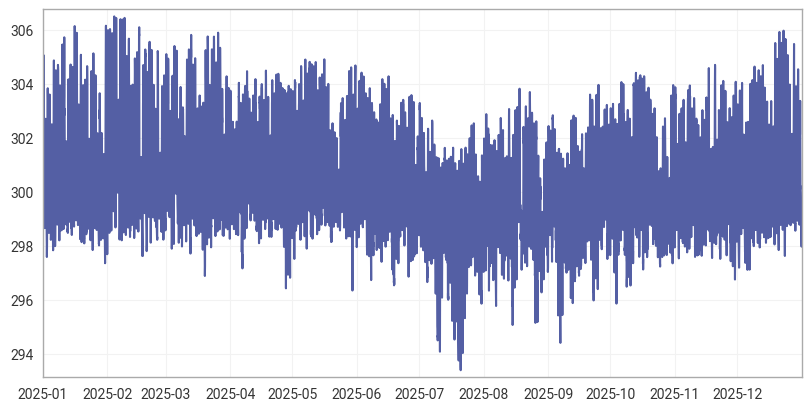

In [14]:
chart = ekp.TimeSeries()

# Plot our hourly data as a line
chart.line(data)

chart.show()

C:\Users\acer\AppData\Local\Temp\ipykernel_21784\1223070441.py:1: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()


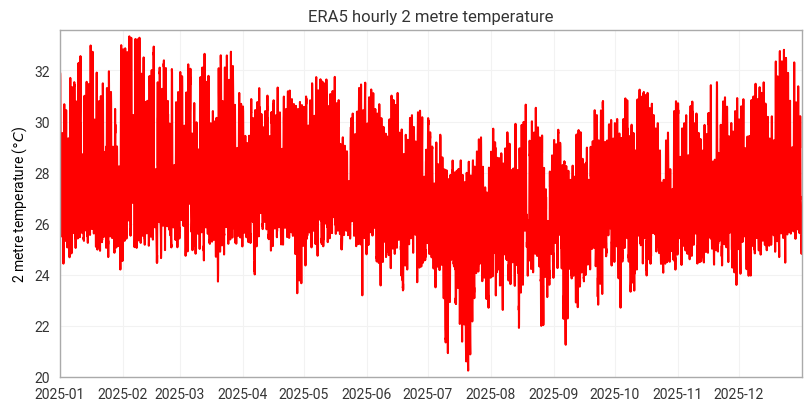

In [15]:
chart = ekp.TimeSeries()

chart.line(
    data,
    units="celsius",
    color="red",
)

# The label string is automatic, based on the data and the units
chart.ylabel()

# You can use metadata templating in titles just like with map plots
chart.title("ERA5 hourly {variable_name}")

chart.show()